# Downstream SVM Task

In [1]:
import torch
import torch.optim as optim
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from dataloaders.simclr import ssl_data_prep
from dataloaders import  save_loader_to_disk
from models.ssl_transformer import SSL_Transformer
from training.train import train_ssl_model
from info_nce import InfoNCE
import wandb
%load_ext autoreload
%autoreload 2  

In [2]:
# Setup Configuration
DATA_ROOT = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020/data")
RESULTS_PATH = DATA_ROOT / "IY020_simulation_parameters_sobol.csv" #  this csv file stores all the simulation parameters used
df_params = pd.read_csv(RESULTS_PATH) 
# filter out only successful simulations with no error_message, and mean_rel_error_pct < 10, cv_rel_error_pct  < 10, & t_ac_rel_error_pct < 10
df_params = df_params[(df_params['success'] == True) & 
                    (df_params['error_message'].isna()) &
                    (df_params['mean_rel_error_pct'] < 10) & 
                    (df_params['cv_rel_error_pct'] < 10) & 
                    (df_params['t_ac_rel_error_pct'] < 10)]
TRAJ_PATH = [DATA_ROOT / df_params['trajectory_filename'].values[i] for i in range(len(df_params))]
TRAJ_NPZ_PATH = [traj_file.with_suffix('.npz') for traj_file in TRAJ_PATH]
print(f"Number of VALID trajectories: {len(TRAJ_PATH)}")

Number of VALID trajectories: 7709


In [3]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = None

train_loader, val_loader, test_loader = ssl_data_prep(
    TRAJ_NPZ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===

In [4]:
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)
# === Model hyperparams ===
input_size = X1_b.shape[2] 
num_classes = 2
d_model=16
nhead=4
num_layers=2
dropout=0.01
use_conv1d=False 

model = SSL_Transformer(
    input_size=input_size,   
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout,
    use_conv1d=use_conv1d,
)
# === Model hyperparams ===

# === Training hyperparams ===
epochs = 50
patience = 50 // 3 # SSL may benefit from high patience
lr = 1e-2 
optimizer = optim.Adam(model.parameters(), lr=lr)

# Cosine Annealing LR Scheduler (good default for SSL)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
# scheduler = None
# 1. simple scheduler choice
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience= patience // 3, factor=0.5) 

# 2. cosine scheduler with warmup, most commonly used for transformer
warmup_steps = int(0.1 * epochs)   # 10% warmup (good default)
from transformers import get_cosine_schedule_with_warmup
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=epochs,
) 

nce_temp = 0.2
loss_fn = InfoNCE(negative_mode='unpaired', temperature=nce_temp)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
grad_clip = None

from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = f'IY017_simCLR_b{batch_size}_lr{lr}_L{num_layers}_H{nhead}_D{d_model}_{timestamp}_model.pth'
save_path = model_path
verbose = True

model.to(device)
# === Training hyperparams ===

torch.Size([64, 1811, 1]) torch.Size([64, 1811, 1]) torch.Size([64, 1])


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SSL_Transformer(
  (backbone): TransformerClassifier(
    (input_proj): Linear(in_features=1, out_features=16, bias=True)
    (pe): PositionalEncoding()
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
          )
          (linear1): Linear(in_features=16, out_features=64, bias=True)
          (dropout): Dropout(p=0.01, inplace=False)
          (linear2): Linear(in_features=64, out_features=16, bias=True)
          (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.01, inplace=False)
          (dropout2): Dropout(p=0.01, inplace=False)
        )
      )
    )
    (dropout): Dropout(p=0.01, inplace=False)
    (head): Linear(in_features=16, out_features=2, bias=True)
  )
  (

In [ ]:
trained_model_paths = ['IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth', 
                       'IY017_simCLR_b64_lr0.01_L2_H4_D16_20260215_163742_model.pth', # batch size 64, instance norm
                       f'IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth', # batch size 128
                       'IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth',
                       'IY017_simCLR_b512_lr0.01_L2_H4_D16_20260219_154043_model.pth',
                       'IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth',
                       'IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth',
                       'IY017_simCLR_b4096_lr0.01_L2_H4_D16_20260221_140729_model.pth', 
                       'IY017_simCLR_b4096_lr0.01_L2_H4_D16_20260225_023947_model.pth' # no instance norm
                       ]

In [ ]:
# save the trained model
# torch.save(model.state_dict(), model_path)
# load the trained model
# trained_model_path = 'IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth'
# trained_model_path = f'IY017_simCLR_b64_lr0.01_L2_H4_D16_20260215_163742_model.pth' # batch size 64
# trained_model_path = f'IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth' # batch size 128
# trained_model_path = 'IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth'
# trained_model_path = 'IY017_simCLR_b512_lr0.01_L2_H4_D16_20260219_154043_model.pth'
# trained_model_path = 'IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth'
# trained_model_path = 'IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth'
# trained_model_path = 'IY017_simCLR_b4096_lr0.01_L2_H4_D16_20260221_140729_model.pth'
# trained_model_path= trained_model_paths[-1] # change this to load different trained models
# model.load_state_dict(torch.load(trained_model_path))

<All keys matched successfully>

Downstream SVM:

Encoder to extract features, then train SVM on those features to predict the parameters. Compare to SVM trained on catch22 features.

In [6]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm import tqdm

from dataloaders.baseline import baseline_data_prep
from models.ssl_transformer import SSL_Transformer

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DATA_BASE_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020")

INPUT_SIZE = input_size
D_MODEL = d_model
NHEAD = nhead
NUM_LAYERS = num_layers
DROPOUT = dropout
USE_CONV1D = use_conv1d
DEVICE = device

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def load_trained_model(checkpoint_path, device):
    """Instantiates the model and loads weights."""
    print(f"Loading model from {checkpoint_path}...")
    model = SSL_Transformer(
        input_size=INPUT_SIZE,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        use_conv1d=USE_CONV1D
    )
    try:
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
    except Exception as e:
        print(f"Error loading state dict: {e}")
        raise e
    model.to(device)
    model.eval()
    return model


def extract_ssl_features(model, loader, device):
    """
    Extracts features for pairs (x1, x2) using the frozen SSL encoder.
    Feature = |Embed(x1) - Embed(x2)|
    """
    features_list = []
    labels_list = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting SSL Features", leave=False):
            X_batch, y_batch = batch
            X_batch = X_batch.to(device)

            x1 = X_batch[:, :, 0].unsqueeze(-1)
            x2 = X_batch[:, :, 1].unsqueeze(-1)

            if hasattr(model, 'encode'):
                z1 = model.encode(x1)
                z2 = model.encode(x2)
            else:
                z1 = model.backbone(x1).mean(dim=1)
                z2 = model.backbone(x2).mean(dim=1)

            feat = torch.abs(z1 - z2)
            feat_np = feat.cpu().numpy()
            if feat_np.ndim == 1:
                feat_np = feat_np.reshape(-1, 1)

            features_list.append(feat_np)
            labels_list.append(y_batch.cpu().numpy())

    return np.concatenate(features_list, axis=0), np.concatenate(labels_list, axis=0)


def train_and_evaluate_svm(train_loader, test_loader, model, device, task_name="Task"):
    """Pipeline: Extract Features -> Scale -> Train SVM -> Evaluate"""
    print(f"\n=== Processing {task_name} ===")

    print(f"   [1/4] Extracting Train Features...")
    X_train, y_train = extract_ssl_features(model, train_loader, device)

    print(f"   [2/4] Extracting Test Features...")
    X_test, y_test = extract_ssl_features(model, test_loader, device)

    print(f"   [3/4] Scaling Data...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"   [4/4] Training SVM & Evaluating...")
    clf = SVC(kernel='rbf', C=1.0)
    clf.fit(X_train_scaled, y_train.ravel())

    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"   >> {task_name} Accuracy: {acc:.2%}")
    return acc


def make_loaders(data_root: Path, results_csv: str):
    """Helper to create loaders for a specific dataset folder."""
    results_path = data_root / results_csv
    if not results_path.exists():
        print(f"Warning: Could not find {results_path}, skipping...")
        return None, None, None

    df_params = pd.read_csv(results_path)
    df_params = df_params[
        (df_params['success'] == True) &
        (df_params['error_message'].isna()) &
        (df_params['mean_rel_error_pct'] < 10) &
        (df_params['cv_rel_error_pct'] < 10) &
        (df_params['t_ac_rel_error_pct'] < 10)
    ]
    traj_paths = [data_root / fname for fname in df_params['trajectory_filename'].values]
    traj_npz_paths = [p.with_suffix('.npz') for p in traj_paths]

    train_l, val_l, test_l = baseline_data_prep(
        traj_npz_paths,
        batch_size=batch_size,
        num_groups_train=3000,
        num_groups_test=600,
        num_traj=2,
        pos_ratio=0.5,
        sample_len=500,
        stack_axis=1,
        verbose=False
    )
    return train_l, val_l, test_l


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

experiments = [
    {"name": "Baseline",      "folder": "data",              "csv": "IY020_simulation_parameters_sobol.csv"},
    {"name": "CV Variation",  "folder": "data_cv_variation", "csv": "IY020_simulation_cv_parameters_sobol.csv"},
    {"name": "Mu Variation",  "folder": "data_mu_variation", "csv": "IY020_simulation_mu_parameters_sobol.csv"},
    {"name": "T_ac Variation","folder": "data_t_ac_variation","csv": "IY020_simulation_t_ac_parameters_sobol.csv"},
]

# Collect results across all models: {model_label: {task_name: accuracy}}
all_results = {}

for MODEL_CHECKPOINT_PATH in trained_model_paths:
    model_label = Path(MODEL_CHECKPOINT_PATH).stem

    ssl_model = load_trained_model(MODEL_CHECKPOINT_PATH, DEVICE)

    results = {}
    for exp in experiments:
        data_path = DATA_BASE_DIR / exp["folder"]
        train_loader, _, test_loader = make_loaders(data_path, exp["csv"])
        if train_loader:
            acc = train_and_evaluate_svm(train_loader, test_loader, ssl_model, DEVICE, task_name=exp["name"])
            results[exp["name"]] = acc

    all_results[model_label] = results

    print("\n" + "="*30)
    print(f"RESULTS: {model_label}")
    print("="*30)
    for name, acc in results.items():
        print(f"{name:.<20} {acc:.2%}")

Loading model from IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth...

=== Processing Baseline ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> Baseline Accuracy: 52.33%

=== Processing CV Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> CV Variation Accuracy: 62.17%

=== Processing Mu Variation ===
   [1/4] Extracting Train Features...


...

   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> CV Variation Accuracy: 50.17%

=== Processing Mu Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> Mu Variation Accuracy: 48.00%

=== Processing T_ac Variation ===
   [1/4] Extracting Train Features...


   [2/4] Extracting Test Features...


   [3/4] Scaling Data...
   [4/4] Training SVM & Evaluating...
   >> T_ac Variation Accuracy: 49.50%

RESULTS: IY017_simCLR_b4096_lr0.01_L2_H4_D16_20260225_023947_model
Baseline............ 52.17%
CV Variation........ 50.17%
Mu Variation........ 48.00%
T_ac Variation...... 49.50%


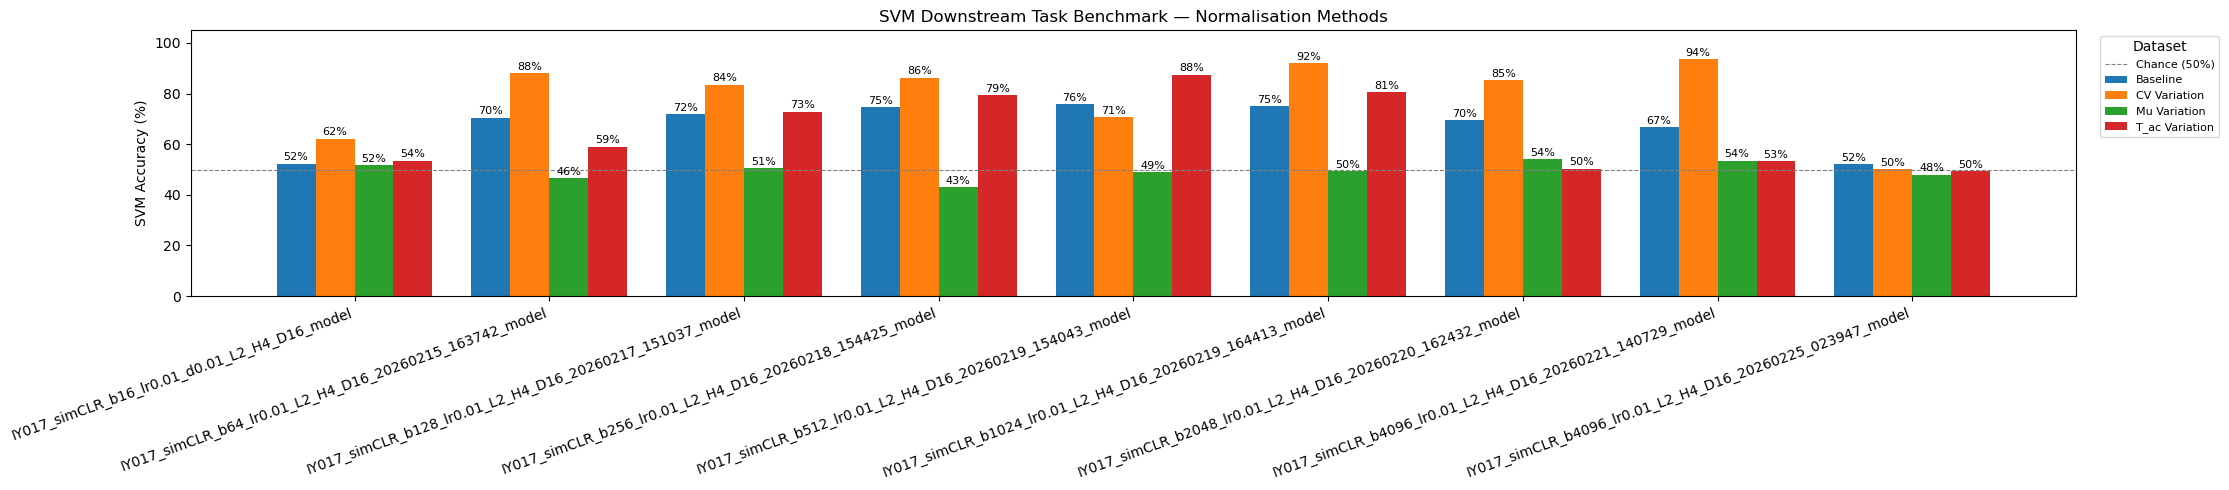

In [7]:
# ==============================================================================
# BENCHMARK PLOT: SVM accuracy across models and tasks
# x-axis = models, bars = datasets/tasks
# ==============================================================================

model_labels = list(all_results.keys())
task_names = [exp["name"] for exp in experiments]

n_models = len(model_labels)
n_tasks = len(task_names)
x = np.arange(n_models)
bar_width = 0.8 / n_tasks  # total group width = 80%

fig, ax = plt.subplots(figsize=(max(10, n_models * 2.5), 5))

for i, task in enumerate(task_names):
    accs = [all_results[m].get(task, np.nan) for m in model_labels]
    offsets = (i - (n_tasks - 1) / 2) * bar_width
    bars = ax.bar(
        x + offsets,
        [a * 100 if not np.isnan(a) else 0 for a in accs],
        width=bar_width,
        label=task,
    )

    # Annotate each bar
    for bar, acc in zip(bars, accs):
        if not np.isnan(acc):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{acc:.0%}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

ax.axhline(50, color="grey", linestyle="--", linewidth=0.8, label="Chance (50%)")
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=20, ha="right")
ax.set_ylabel("SVM Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("SVM Downstream Task Benchmark — Normalisation Methods")
ax.legend(title="Dataset", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
